In [2]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [3]:
import sys

sys.path.append('../scripts')

In [4]:
import numpy as np
import scanpy as sc
import os
import matplotlib.pyplot as plt
import decoupler as dc
import scipy.sparse as sp
import pandas as pd

from scipy.stats import pearsonr, spearmanr

from utils import set_seed
from train_loo import preprocess_crc, preprocess_merfish, _load_model, split_indices
from counterfactual_analysis import compute_rmse, compute_edistance, mixing_index, get_lfc, precision, direction_match, compute_mse_lfc, _to_dense
from configs.adata_crc_config import ADATA_ARGS as ADATA_ARGS_CRC
from configs.adata_merfish_config import ADATA_ARGS as ADATA_ARGS_MERFISH

/data/a330d/miniforge3/envs/cellina-graph/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import cellina
import cellina_graph

cellina.__version__, cellina_graph.__version__

('0.7.3', '0.0.9')

In [6]:
set_seed(0)

In [7]:
DATASET_NAME = "merfish"  # or "merfish"
MODEL_ROOT = "/data/a330d/data/ood/trained"

In [8]:
CRC_PATHS = [
    #"/data2/a330d/datasets/crc/raw_zenodo/crc_210.h5ad",
    #"/data2/a330d/datasets/crc/raw_zenodo/crc_221.h5ad",
    "/data2/a330d/datasets/crc/raw_zenodo/crc_231.h5ad",
    "/data2/a330d/datasets/crc/raw_zenodo/crc_232.h5ad",
    "/data2/a330d/datasets/crc/raw_zenodo/crc_242.h5ad",
    #"/data2/a330d/datasets/crc/raw_zenodo/crc_120.h5ad",
]

CRC_HOLDOUTS = [
    "Endothelial",
    "Epithelial",
    "Fibroblast",
    "Myeloid",
    "T_cell",
]

MERFISH_PATHS = [
    "/data/a330d/datasets/MERFISH_mouse_brain/C57BL6J-2.036.h5ad",    
    "/data/a330d/datasets/MERFISH_mouse_brain/C57BL6J-2.039.h5ad",
    "/data/a330d/datasets/MERFISH_mouse_brain/C57BL6J-2.041.h5ad",
]

MERFISH_HOLDOUTS = [
    'glutamatergic neuron',
    'oligodendrocyte',
    'astrocyte',
    'GABAergic neuron',
    'endothelial cell',
]

PATHS = CRC_PATHS if DATASET_NAME == "crc" else MERFISH_PATHS
HOLDOUT_CELLTYPES = CRC_HOLDOUTS if DATASET_NAME == "crc" else MERFISH_HOLDOUTS
DATA_ARGS = ADATA_ARGS_CRC if DATASET_NAME == "crc" else ADATA_ARGS_MERFISH
COUNTS_PER_K = 1e4

In [9]:
n_top_genes = DATA_ARGS.get('n_top_genes')
labels_key = DATA_ARGS.get('labels_key')
domains_key = DATA_ARGS.get('domains_key')
batch_key = DATA_ARGS.get('batch_key')
control_domain = DATA_ARGS.get('control_domains')[0]
holdout_domains = DATA_ARGS.get('holdout_domains')
n_neighbors = DATA_ARGS.get('n_neighbors')
batch_size = 1024
library_size = 'latent'
n_deg = 50

In [10]:
# Create SLIDES which contain file names from PATHS - first split by "/" and take last part, then split by "." and take first part
SLIDES = [path.split("/")[-1].split(".h5ad")[0] for path in PATHS]

In [11]:
model_names = ['cellina', 'cellina-ablated', 'cellina-graph']
results = []
for path, slide_id in zip(PATHS, SLIDES):
    adata = sc.read(path)
    
    if DATASET_NAME == 'crc':
        adata = preprocess_crc(adata, n_top_genes=n_top_genes, n_neighbors=n_neighbors, labels_key=labels_key, domains_key=domains_key)
    elif DATASET_NAME == 'merfish':
        adata = preprocess_merfish(adata, n_top_genes=n_top_genes, n_neighbors=n_neighbors, labels_key=labels_key, domains_key=domains_key)
    else:
        raise ValueError(f"Unknown dataset_name: {DATASET_NAME}. Supported: crc, merfish")
    
    for model_name in model_names:
        if model_name == 'cellina-ablated' or model_name == 'cellina':
            model_class = 'cellina'
        else:
            model_class = 'cellina_graph'
        for holdout_celltype in HOLDOUT_CELLTYPES:
            # 50 times * in print
            print(f"{'='*50} Slide: {slide_id}, Holdout Celltype: {holdout_celltype} {'='*50}")
            # create splits
            train_idx, val_idx, test_idx = split_indices(adata,
                                                        holdout_celltype,
                                                        labels_key=labels_key,
                                                        domains_key=domains_key,
                                                        holdout_domains=holdout_domains,
                                                        seed=0)

            splits = (train_idx, val_idx, test_idx)

            save_dir = os.path.join(MODEL_ROOT, slide_id, holdout_celltype, model_name)
            
            try:
                model = _load_model(save_dir,
                                    model_class=model_class,
                                    adata=adata,
                                    splits=splits)
            except Exception as e:
                print(f"Failed to load model from {save_dir} with error: {e}")
                continue
            is_control_region = adata.obs[domains_key]==(control_domain)
            is_holdout_ct = adata.obs[labels_key].astype(str) == holdout_celltype
            mask_control = is_control_region & is_holdout_ct
            idx_control = np.where(mask_control.values)[0]    
            
            for hd in holdout_domains:
                    is_holdout_region = adata.obs[domains_key].astype(str) == hd
                    mask_ct_target = is_holdout_ct & is_holdout_region
                    mask_global_target = is_holdout_region & ~is_holdout_ct
                    idx_target = np.where(mask_ct_target.values)[0]

                    # "neighbour_indices" are indices of the neighbors of idx_target cells
                    conn = adata.obsp["spatial_connectivities"]
                    sub_conn = conn[idx_target]                # rows for target cells
                    neighbor_indices = sub_conn.nonzero()[1]   # all neighbors at once
                    neighbor_indices = np.unique(neighbor_indices)
                    # keep only non-holdout-ct neighbors
                    neighbor_indices = neighbor_indices[~is_holdout_ct.values[neighbor_indices]]

                    args_gex = {
                        "indices": idx_control,
                        "batch_size": batch_size,
                        "seed": 0,
                    }
                    if model_class.lower() == 'cellina_graph':
                        args_gex["n_neighbors_per_seed"] = 50
                        args_gex["neighbour_indices"] = neighbor_indices
                    else:
                        args_gex["adata"] = adata
                        args_gex["neighbour_indices"] = neighbor_indices
                        args_gex['precomputed'] = False
                    
                    cf_counts = model.get_counterfactual_expression(**args_gex)
                    
                    # Compute stats
                    control = adata.layers['counts'][mask_control.values, :]
                    target = adata.layers['counts'][mask_ct_target.values, :]
                    control, target = _to_dense(control), _to_dense(target)
                    counterfactual = cf_counts

                    gt_lfc, cf_lfc, deg = get_lfc(control=control, target=target, counterfactual=counterfactual, n_deg=n_deg)

                    spear, _ = spearmanr(gt_lfc[deg], cf_lfc[deg])
                    pear, _ = pearsonr(gt_lfc[deg], cf_lfc[deg])
                    prec = precision(gt_lfc, cf_lfc, k=n_deg, use_abs=True)
                    dir_match = direction_match(gt_lfc, cf_lfc, k=n_deg, normalize="intersection")
                    dir_match_k = direction_match(gt_lfc, cf_lfc, k=n_deg, normalize="k")
                    dir_match_gt = direction_match(gt_lfc, cf_lfc, k=n_deg, normalize="gt_topk")
                    mix_idx = mixing_index(observed=target, predicted=counterfactual, library_size=COUNTS_PER_K)
                    edist_global = compute_edistance(adata, observed=target, predicted=counterfactual, deg=None, library_size=COUNTS_PER_K)
                    edist_local = compute_edistance(adata, observed=target, predicted=counterfactual, deg=None, library_size=COUNTS_PER_K, local=True)
                    edist_pca_log = compute_edistance(adata, observed=target, predicted=counterfactual, deg=None, library_size=COUNTS_PER_K, local=True, use_pca=True)
                    edist_pca = compute_edistance(adata, observed=target, predicted=counterfactual, deg=None, library_size=COUNTS_PER_K, local=True, use_pca=True, log1p=False)
                    rmse = compute_rmse(observed=target, predicted=counterfactual, deg=deg, library_size=COUNTS_PER_K)
                    mse_lfc = compute_mse_lfc(gt_vec=gt_lfc, cf_vec=cf_lfc, deg=deg)

                    results.append(
                            dict(
                            dataset_name=DATASET_NAME,
                            sid=slide_id,
                            control_domain=control_domain,
                            target_domain=hd,
                            n_deg=n_deg,
                            model_name=model_name,
                            holdout_celltype=holdout_celltype,
                            spearman=spear,
                            pearson=pear,
                            precision=prec,
                            direction_match=dir_match,
                            direction_match_k=dir_match_k,
                            direction_match_gt=dir_match_gt,
                            mixing_index=mix_idx,
                            edistance_global=edist_global,
                            edistance_local=edist_local,
                            edistance_pca_log=edist_pca_log,
                            edistance_pca=edist_pca,
                            rmse=rmse,
                            mse_lfc=mse_lfc,
                            )
                    )

/data/a330d/projects/cellina-reproducibility/notebooks/../scripts/train_loo.py:175: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[labels_key] = adata.obs[labels_key].astype("category")
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


================================================== Slide: C57BL6J-2.036, Holdout Celltype: glutamatergic neuron ==================================================
INFO     File /data/a330d/data/ood/trained/C57BL6J-2.036/glutamatergic neuron/cellina/model.pt already downloaded  
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        
cellina loaded model from /data/a330d/data/ood/trained/C57BL6J-2.036/glutamatergic neuron/cellina


/data/a330d/miniforge3/envs/cellina-graph/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 17 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(


INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


...

/data/a330d/miniforge3/envs/cellina-graph/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 16 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
/data/a330d/miniforge3/envs/cellina-graph/lib/python3.11/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(
/data/a330d/miniforge3/envs/cellina-graph/lib/python3.11/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU i

================================================== Slide: C57BL6J-2.041, Holdout Celltype: GABAergic neuron ==================================================
INFO     File /data/a330d/data/ood/trained/C57BL6J-2.041/GABAergic neuron/cellina-graph/model.pt already downloaded
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting with edge prediction   
cellina_graph loaded model from /data/a330d/data/ood/trained/C57BL6J-2.041/GABAergic neuron/cellina-graph


/data/a330d/miniforge3/envs/cellina-graph/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 16 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
/data/a330d/miniforge3/envs/cellina-graph/lib/python3.11/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(
/data/a330d/miniforge3/envs/cellina-graph/lib/python3.11/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU i

================================================== Slide: C57BL6J-2.041, Holdout Celltype: endothelial cell ==================================================
INFO     File /data/a330d/data/ood/trained/C57BL6J-2.041/endothelial cell/cellina-graph/model.pt already downloaded
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting with edge prediction   
cellina_graph loaded model from /data/a330d/data/ood/trained/C57BL6J-2.041/endothelial cell/cellina-graph


/data/a330d/miniforge3/envs/cellina-graph/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:227: UserWarning: Category 16 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
/data/a330d/miniforge3/envs/cellina-graph/lib/python3.11/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(
/data/a330d/miniforge3/envs/cellina-graph/lib/python3.11/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


In [12]:
# Append to existing csv if exists, otherwise create new csv
results_csv_name = f'../results/loo_cellina_{DATASET_NAME}_DEG_{n_deg}_strict_cf.csv'

df_results = pd.DataFrame(results)
if os.path.exists(results_csv_name):
    df_results.to_csv(f"{results_csv_name}", index=False, mode='a', header=False)
else:
    df_results.to_csv(f"{results_csv_name}", index=False)

## Better Looking

In [28]:
DATASET_NAME = "merfish"
MODEL_NAME = "cellina"
n_deg = 50

old = pd.read_csv(f'../results/loo_summary_{DATASET_NAME}_DEG_{n_deg}.csv')
new = pd.read_csv(f'../results/loo_cellina_{DATASET_NAME}_DEG_{n_deg}_strict_cf.csv')

slides = new['sid'].unique().tolist()
old = old[(old['model_name'] == MODEL_NAME) & (old['sid'].isin(slides))].copy()
new = new[(new['model_name'] == MODEL_NAME) & (new['sid'].isin(slides))].copy()

old['rmse']    = old['rmse'].apply(lambda x: np.log10(x) if x > 0 else 0)
new['rmse']    = new['rmse'].apply(lambda x: np.log10(x) if x > 0 else 0)
new['mse_lfc'] = new['mse_lfc'].apply(lambda x: np.sqrt(x) if x > 0 else 0)
old['mse_lfc'] = old['mse_lfc'].apply(lambda x: np.sqrt(x) if x > 0 else 0)

In [29]:
metrics = ['pearson', 'spearman', 'direction_match_k', 'edistance_pca_log', 'rmse', 'mse_lfc']

pretty_names = {
    'pearson':           r'Pearson $r$ $\uparrow$',
    'spearman':          r'Spearman $\rho$ $\uparrow$',
    'direction_match_k': r'Signed Precision $\uparrow$',
    'edistance_pca_log': r'E-distance $\downarrow$',
    'rmse':              r'$\mathrm{RMSE}_{\mathrm{counts}}$ $\downarrow$',
    'mse_lfc':           r'$\mathrm{RMSE}_{\mathrm{LFC}}$ $\downarrow$',
}

ct_means   = {m: old[m].mean() for m in metrics}
rand_means = {m: new[m].mean() for m in metrics}

ct_se   = {m: old[m].sem() for m in metrics}
rand_se = {m: new[m].sem() for m in metrics}

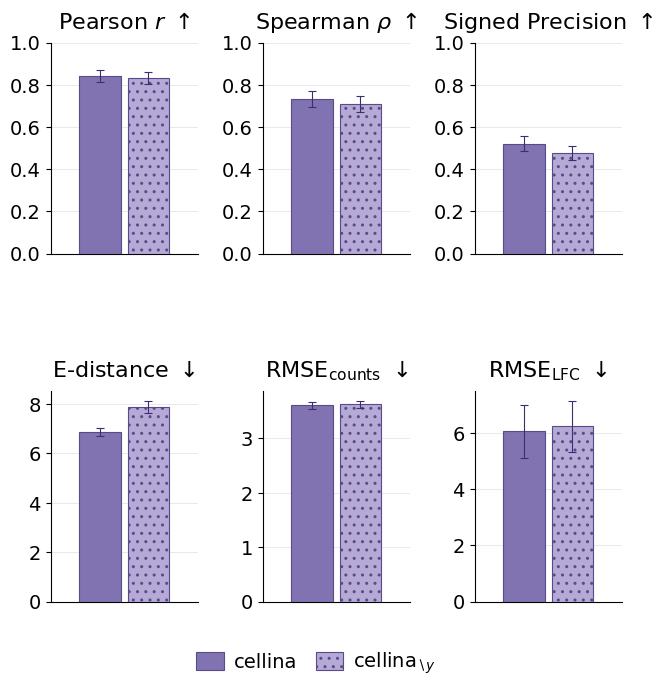

In [30]:
import matplotlib as mpl
import matplotlib.patches as mpatches
import math

mpl.rcParams.update({
    'font.family':       'sans-serif',
    'font.sans-serif':   ['Helvetica', 'Arial'],
    'font.size':         16,
    'axes.titlesize':    16,
    'axes.labelsize':    14,
    'xtick.labelsize':   14,
    'ytick.labelsize':   14,
    'legend.fontsize':   14,
    'axes.linewidth':    0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'svg.fonttype':      'none',
})

COLOR_CT   = '#8172B2'
COLOR_RAND = '#B5A9D6'
EDGE_COLOR = '#5B4A8A'

bounded_metrics = {'pearson', 'spearman', 'direction_match_k'}

bar_width = 0.35
gap       = 0.06
x_ct      = -(bar_width / 2 + gap / 2)
x_rand    =  (bar_width / 2 + gap / 2)
margin    = bar_width * 0.7

n_metrics = len(metrics)
ncols     = math.ceil(n_metrics / 2)
nrows     = 2

fig, axes = plt.subplots(nrows, ncols, figsize=(2.2 * ncols, 7.0))

# Flatten and hide any unused axes (if n_metrics is odd)
axes_flat = axes.flatten()
for j in range(n_metrics, len(axes_flat)):
    axes_flat[j].set_visible(False)

for i, metric in enumerate(metrics):
    ax    = axes_flat[i]
    label = pretty_names[metric]
    v_ct   = ct_means[metric];   e_ct   = ct_se[metric]
    v_rand = rand_means[metric]; e_rand = rand_se[metric]

    err_kw = dict(lw=0.8, capsize=3, capthick=0.8)

    ax.bar(x_ct, v_ct, width=bar_width,
           color=COLOR_CT, edgecolor=EDGE_COLOR, linewidth=0.8,
           yerr=e_ct, error_kw=dict(ecolor='#3D2D6E', **err_kw), zorder=3)

    ax.bar(x_rand, v_rand, width=bar_width,
           color=COLOR_RAND, edgecolor=EDGE_COLOR, linewidth=0.8,
           hatch='..', yerr=e_rand,
           error_kw=dict(ecolor='#3D2D6E', **err_kw), zorder=3)

    ax.set_xlim(x_ct - bar_width / 2 - margin,
                x_rand + bar_width / 2 + margin)
    ax.set_xticks([])
    ax.set_title(label, pad=10)
    ax.grid(axis='y', linewidth=0.4, alpha=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

    if metric in bounded_metrics:
        ax.set_ylim(0, 1)

# ── Legend ────────────────────────────────────────────────────────────────────
patch_ct   = mpatches.Patch(facecolor=COLOR_CT,   edgecolor=EDGE_COLOR,
                            linewidth=0.8, label=MODEL_NAME)
patch_rand = mpatches.Patch(facecolor=COLOR_RAND, edgecolor=EDGE_COLOR,
                            linewidth=0.8, hatch='..',
                            label=MODEL_NAME + r'$_{\setminus y}$')

fig.legend(handles=[patch_ct, patch_rand],
           ncol=2, loc='lower center',
           bbox_to_anchor=(0.5, 0.0),
           frameon=False, handlelength=1.4, handleheight=1.0)

plt.tight_layout()
plt.subplots_adjust(bottom=0.12, hspace=0.65)
plt.savefig(f'../figures/strict_loo_{MODEL_NAME}.svg',
            format='svg', bbox_inches='tight', dpi=300)
plt.show()

In [29]:
# Compare old and new metrics means for pearson, spearman, direction_match_k, edistance_pca_log, rmse, mse_lfc
metrics = ['pearson', 'spearman', 'direction_match_k', 'edistance_pca_log', 'rmse', 'mse_lfc']
comparison = {}
for metric in metrics:
    old_mean = round(old[metric].mean(), 2)
    new_mean = round(df_results[metric].mean(), 2)
    print(f"{metric}: ct_neighbors={old_mean}, random_neighbors={new_mean}, difference={new_mean - old_mean:.2f}")
    comparison[metric] = {
        'ct_neighbors': old_mean,
        'random_neighbors': new_mean,
        'difference': new_mean - old_mean
    }

pearson: ct_neighbors=0.8, random_neighbors=0.79, difference=-0.01
spearman: ct_neighbors=0.73, random_neighbors=0.73, difference=0.00
direction_match_k: ct_neighbors=0.3, random_neighbors=0.28, difference=-0.02
edistance_pca_log: ct_neighbors=6.97, random_neighbors=7.11, difference=0.14
rmse: ct_neighbors=4.2, random_neighbors=4.2, difference=0.00
mse_lfc: ct_neighbors=1.38, random_neighbors=1.4, difference=0.02
